In [69]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import os
import time
from sklearn.metrics import f1_score

import src.utils as utils
from src.model import Nonneg_dyn_dag_learning
from src.baselines import Dynotears

SEED = 10
N_CPUS = os.cpu_count()

np.random.seed(SEED)
random.seed(SEED)

## Auxiliary function

In [70]:
def get_lamb_value(n_nodes, n_samples, times=1):
    return np.sqrt(np.log(n_nodes) / n_samples) * times 

def compute_errsW(W_seq, W_true):
    errs = np.zeros(len(W_seq))
    norm_W_true = np.linalg.norm(W_true)
    for i, W_est in enumerate(W_seq):
        errs[i] = (np.linalg.norm(W_true - W_est)/norm_W_true)**2
    
    return errs

def plot_convergence(W_true, seq_W, diff, acyclicity, matrix='W'):
    errs_W = compute_errsW(seq_W, W_true)

    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1)
    plt.semilogy(diff)
    plt.title(f'Convergence of {matrix}')
    plt.subplot(1,3,2)
    plt.semilogy(errs_W)
    plt.title('Error')
    plt.subplot(1,3,3)
    plt.semilogy(acyclicity)
    plt.title('Acyclicity')
    plt.tight_layout()


def plot_time_matrices(W, A, n_lags, common_title=None):
    """
    Plot adjacency matrix W and the lagged matrices A_k extracted from A.

    Parameters
    ----------
    W : ndarray, shape (N, N)
        Base adjacency matrix.
    A : ndarray, shape (N*n_lags, N)
        Block matrix containing lagged adjacency matrices stacked vertically.
    n_lags : int
        Number of lags (blocks in A).
    common_title : str, optional
        Title for the whole figure.
    """
    N = W.shape[0]
    assert A.shape == (N * n_lags, N), f"A must have shape ({N}x{n_lags}, {N}), got {A.shape}"

    fig, axes = plt.subplots(1, n_lags + 1, figsize=(5*(n_lags+1), 5), squeeze=False)

    # --- Panel 1: W ---
    ax = axes[0, 0]
    im = ax.imshow(W, cmap="viridis", interpolation="nearest")
    ax.set_title("Adjacency matrix W")
    ax.set_xlabel("Nodes")
    ax.set_ylabel("Nodes")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # --- Panels 2..n_lags+1: A_k ---
    for k in range(n_lags):
        Ak = A[k*N:(k+1)*N, :]  # extract block for lag k
        ax = axes[0, k+1]
        im = ax.imshow(Ak, cmap="viridis", interpolation="nearest")
        ax.set_title(f"A_{k+1}")
        ax.set_xlabel("Nodes")
        ax.set_ylabel("Nodes")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # --- Common title ---
    if common_title is not None:
        fig.suptitle(common_title, fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

def print_err(A_est, A_true, thr, matrix='W', not_shd=False):    
    A_est_bin = utils.to_bin(A_est, thr)
    A_true_bin = utils.to_bin(A_true, thr)

    fro_err = utils.compute_norm_sq_err(A_true, A_est)
    fro_err_bin = utils.compute_norm_sq_err(A_true_bin, A_est_bin)

    if not_shd:
        shd = -1    
    else:
        shd, _, _ = utils.count_accuracy(A_true_bin, A_est_bin)
    fscore = f1_score(A_true_bin.flatten(), A_est_bin.flatten())

    print(f'{matrix} | Err: {fro_err:.3f}  -  Err bin: {fro_err_bin:.3f}  -  shd: {shd}  -  fscore: {fscore:.3f}')
    
def plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True):
    print_err(W_est, W_true, thr, matrix='W')
    print_err(A_est, A_true, thr, matrix='A', not_shd=True)

    if plot_matrices:
        plot_time_matrices(W_true, A_true, n_lags, common_title='True matrices')
        plot_time_matrices(W_est, A_est, n_lags, common_title='Est matrices')




## Generating data (as in Learning DAGs and Root from Time-Series)

### Data generation

In [ ]:
# Create the DAG and its adjacency matrix with the given utility
N = 50
T = 5000
g_type='er'
dag_w_range = (.1, .5)
edges = 4*N
n_lags = 4
edges_inter = N
exp_decay = 1.5
lag_w_range = (.1, .4)

W_true, dag, A_true, lag_graphs, X, Y = utils.simulate_svar(N, T, g_type, edges,dag_permute=False, dag_w_range=dag_w_range,
                                                            n_lags=n_lags, er_edges=edges_inter, lag_w_range=lag_w_range,
                                                            exp_decay=exp_decay)

print('Mean norm of X:', np.linalg.norm(X[:-n_lags,:], axis=1).mean())
utils.svar_companion_stability(W_true, A_true, verbose=True)

sigma_max = np.linalg.svd(X, compute_uv=False)[0]
L = (sigma_max ** 2) / T
print(f"Lipschitz constant L = {L:.6f}, stepsize ~ {1/L:.6f} ")

ValueError: Could not generate a stable SVAR model in 100 trials.

In [ ]:
# ratio of failed data generation
cont = 0
trials = 100

for _ in range(trials):
    W_aux, _ = utils.create_dag(N, g_type, edges, w_range=dag_w_range)
    A_aux, _ = utils.create_interslice_graph(N, n_lags, g_type, er_edges=edges_inter, w_range=lag_w_range, exp_decay=exp_decay)

    stable, rho = utils.svar_companion_stability(W_aux, A_aux, verbose=False)
    cont += 1 if not stable else 0

print(f'{cont} out of {trials} trials were unstable ({100*cont/trials:.1f}%)')
        

2 out of 100 trials were unstable (2.0%)


### Print matrices and signals

Average out-degree W: 3.900
Average out-degree A: 0.840


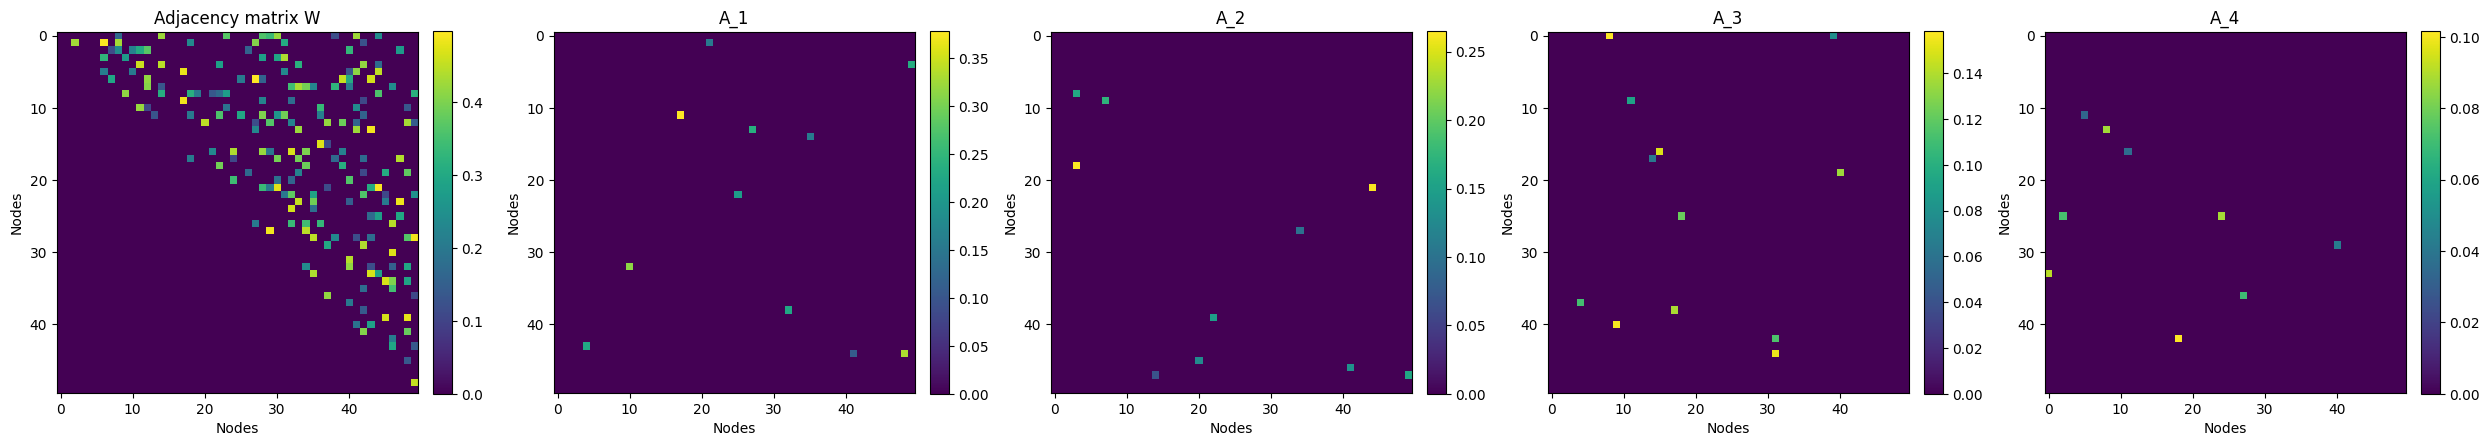

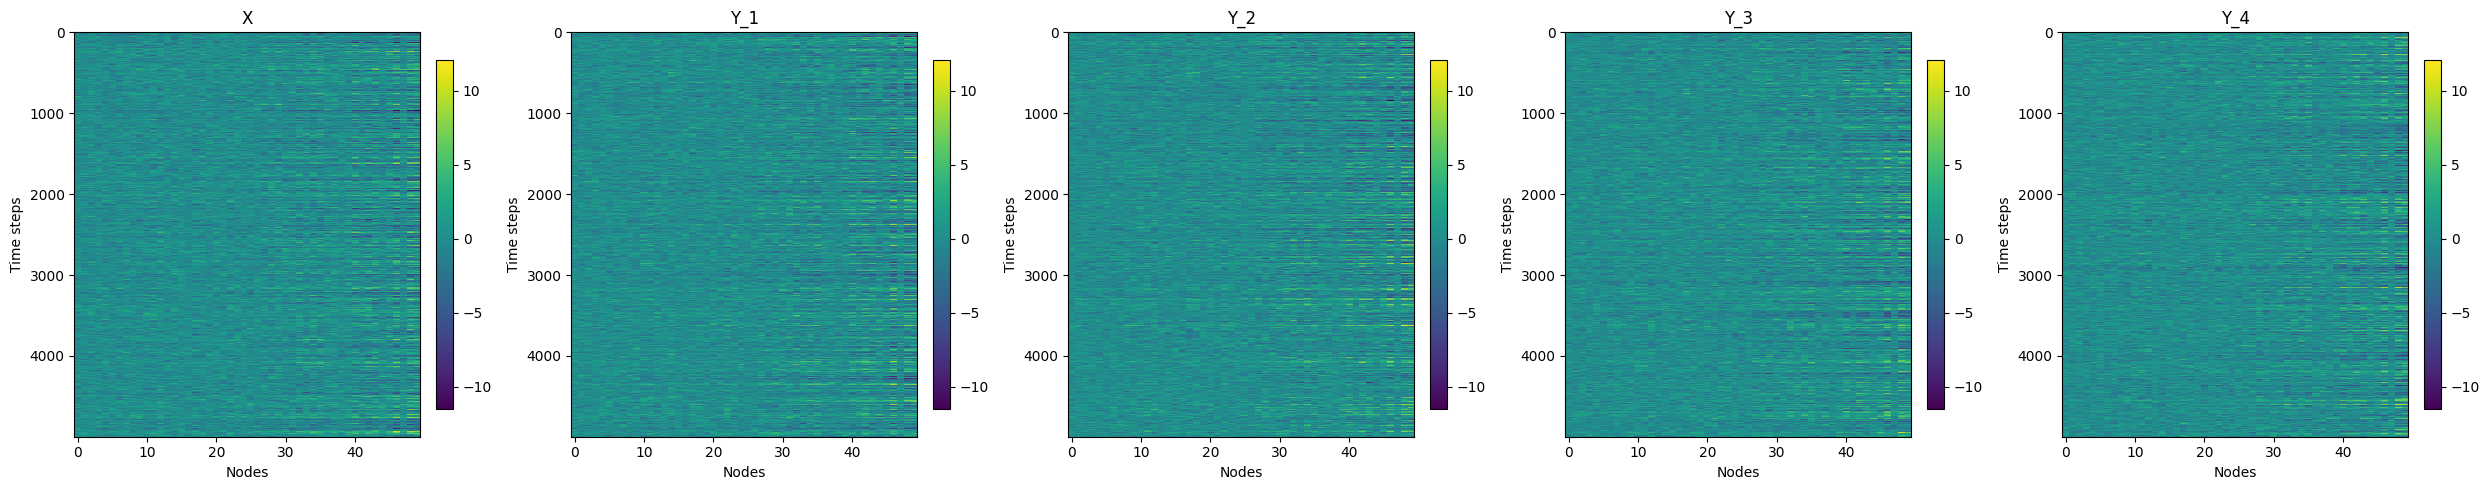

In [ ]:
W_bin = (W_true != 0).astype(int)
A_bin = (A_true != 0).astype(int)
avg_W_deg = W_bin.sum(axis=0).mean()
avg_A_deg = A_bin.sum(axis=0).mean()
print(f"Average out-degree W: {avg_W_deg:.3f}")
print(f"Average out-degree A: {avg_A_deg:.3f}")

plot_time_matrices(W_true, A_true, n_lags, common_title=None)

### Print Signals ###
fig, axes = plt.subplots(1, n_lags + 1, figsize=(5*(n_lags+1), 5), squeeze=False)
# --- Panel 1: X ---
ax = axes[0, 0]
im = ax.imshow(X, cmap="viridis", interpolation="nearest", aspect="auto")
ax.set_title("X")
ax.set_xlabel("Nodes")
ax.set_ylabel("Time steps")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Panels 2..n_lags+1: Y_k ---
for k in range(1, n_lags+1):
    Yk = Y[:, (k-1)*N : k*N]
    ax = axes[0, k]
    im = ax.imshow(Yk, cmap="viridis", interpolation="nearest", aspect="auto")
    ax.set_title(f"Y_{k}")
    ax.set_xlabel("Nodes")
    ax.set_ylabel("Time steps")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Run Nonnegative DAG learning form Time Serie

### DYNOTEARS

In [6]:
t_i = time.time()
model = Dynotears()
W_est, A_est = model.fit(X, Y)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

Solved in 120.453760 seconds


In [9]:
lamb_W = get_lamb_value(N, T, 3.5)
lamb_A = get_lamb_value(N*n_lags, T, 3.3)

print(lamb_W, lamb_A)

0.0979002367887788 0.10015019053941966


W | Err: 0.085  -  Err bin: 0.262  -  shd: 41  -  fscore: 0.865
A | Err: 0.079  -  Err bin: 0.346  -  shd: -1  -  fscore: 0.812


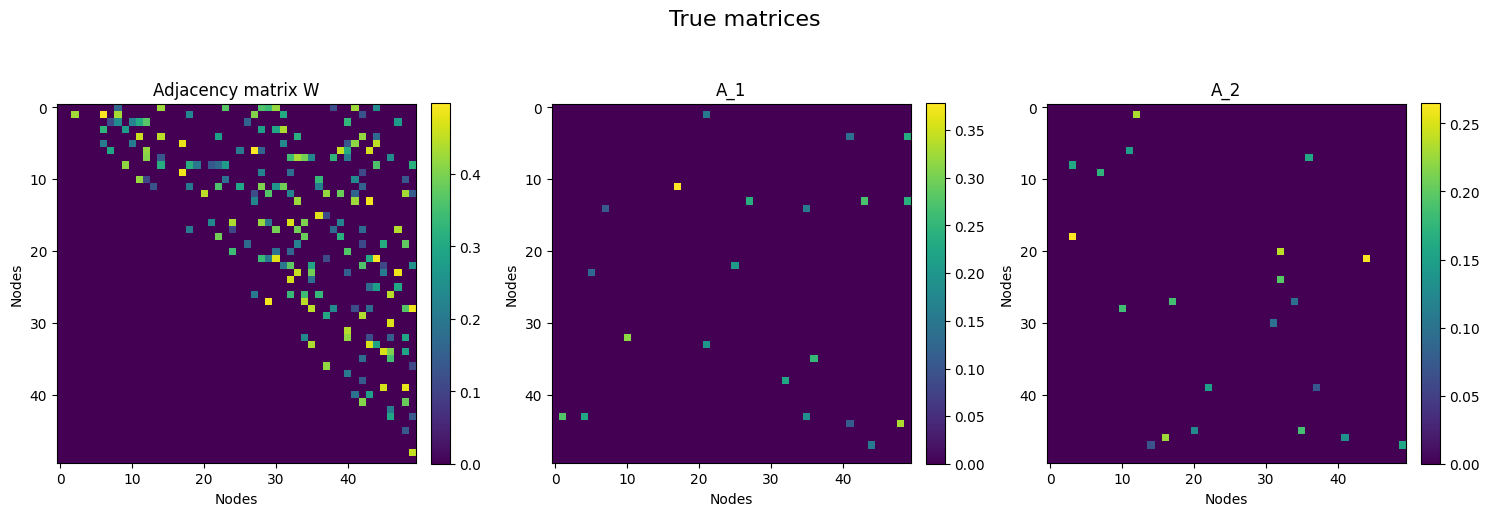

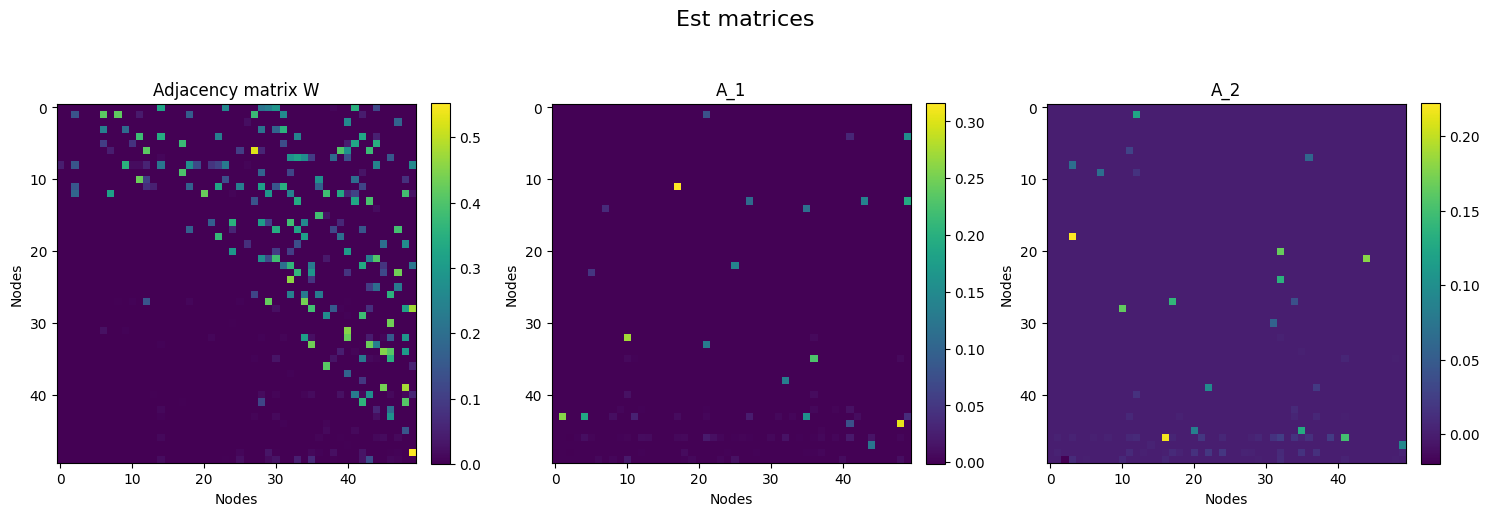

In [7]:
thr = .1
plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)

### Using PGD

lamb_W: 0.00027971496225365374 , lamb_A: 0.0015174271293851467
- 1/20. Diff W: 0.000034 | Diff A: 0.000021 | Acycl: 0.882199 |Rho: 0.250 - Alpha: 1.044 - Step: 0.0005
Convergence achieved at iter 7251
- 2/20. Diff W: 0.000012 | Diff A: 0.000008 | Acycl: 0.158304 |Rho: 0.250 - Alpha: 1.084 - Step: 0.0005
Convergence achieved at iter 751
- 3/20. Diff W: 0.000012 | Diff A: 0.000007 | Acycl: 0.126674 |Rho: 1.250 - Alpha: 1.115 - Step: 0.0005
Convergence achieved at iter 1251
- 4/20. Diff W: 0.000012 | Diff A: 0.000007 | Acycl: 0.072242 |Rho: 6.250 - Alpha: 1.206 - Step: 0.0005
Convergence achieved at iter 1251
- 5/20. Diff W: 0.000012 | Diff A: 0.000007 | Acycl: 0.028369 |Rho: 31.250 - Alpha: 1.383 - Step: 0.0005
Convergence achieved at iter 1001
- 6/20. Diff W: 0.000013 | Diff A: 0.000006 | Acycl: 0.010290 |Rho: 156.250 - Alpha: 1.705 - Step: 0.0005
Convergence achieved at iter 501
- 7/20. Diff W: 0.000014 | Diff A: 0.000005 | Acycl: 0.005453 |Rho: 781.250 - Alpha: 2.557 - Step: 0.0005
Co

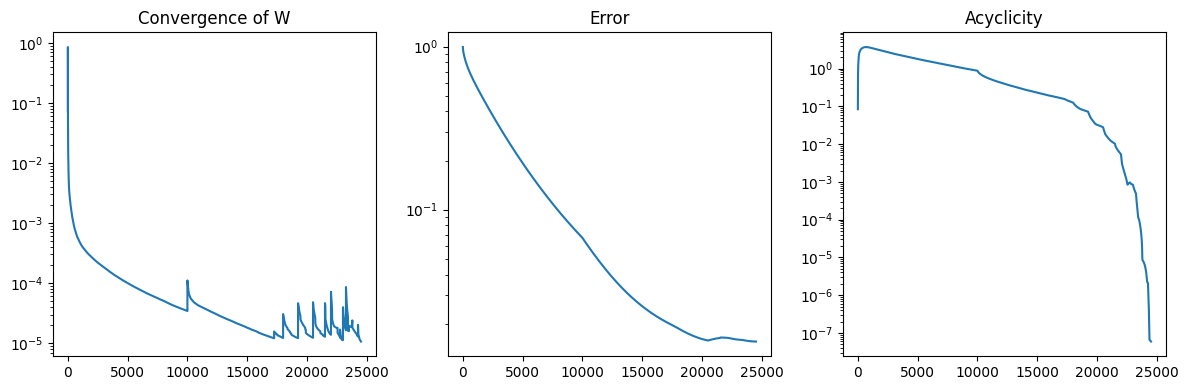

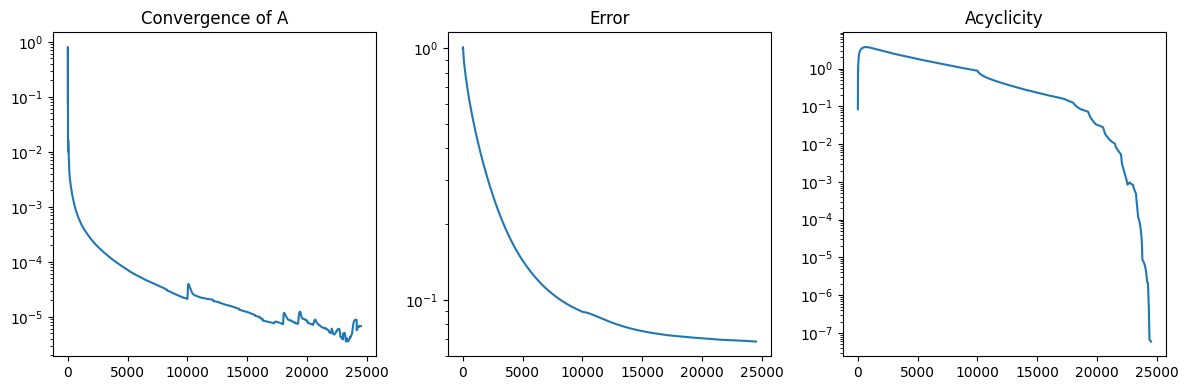

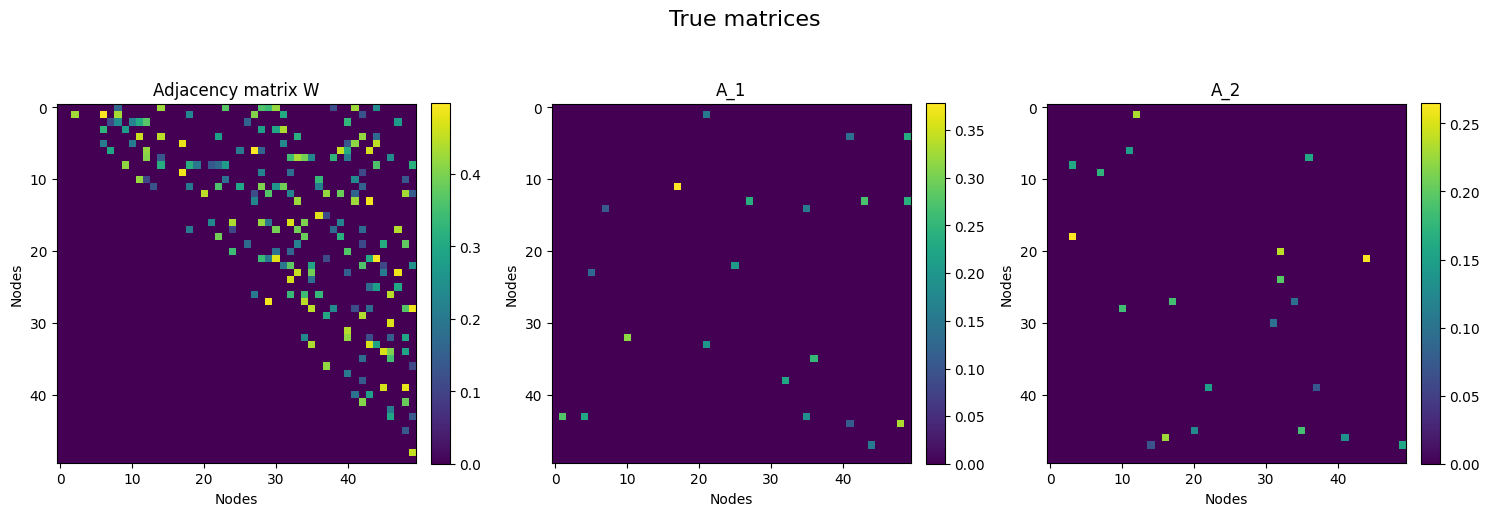

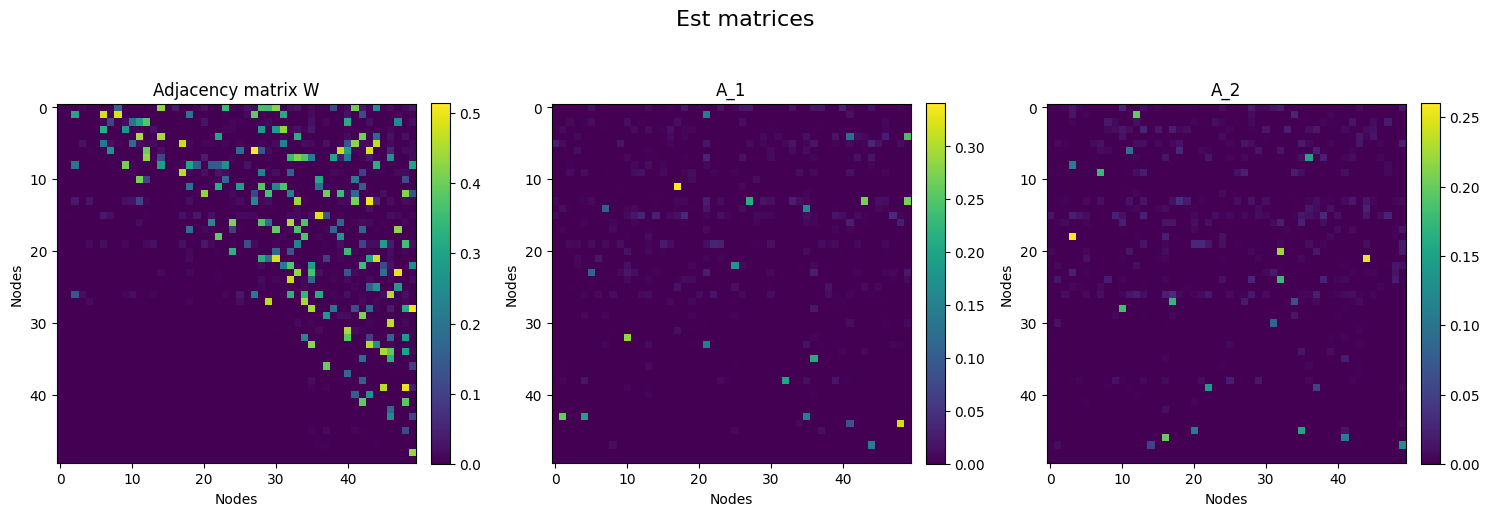

In [8]:
lamb_W = get_lamb_value(N, T, .01)
lamb_A = get_lamb_value(N*n_lags, T, .05)
fit_args = {'stepsize': 5e-4, 'alpha_0': 1, 'rho_0': .05, 's': 1, 'lamb_W': lamb_W, 'lamb_A': lamb_A,
            'iters_in': 10000, 'iters_out': 20, 'tol': 1e-5, 'beta': 5, 'verb': True}

print('lamb_W:', lamb_W, ', lamb_A:', lamb_A)

t_i = time.time()
model = Nonneg_dyn_dag_learning(acyclicity='logdet', primal_opt='pgd')
W_est, A_est = model.fit(X, Y, **fit_args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .1
plot_convergence(W_true, model.seq_W, model.diff_W, model.acyclicity, matrix='W')
plot_convergence(A_true, model.seq_A, model.diff_A, model.acyclicity, matrix='A')

plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)

### Using APGD

lamb_W: 0.00027971496225365374 , lamb_A: 0.0015174271293851467
Convergence achieved at iter 7251
- 1/20. Diff W: 0.000005 | Diff A: 0.000013 | Acycl: 0.131115 |Rho: 0.250 - Alpha: 1.007 - Step: 0.0003
Convergence achieved at iter 1
- 2/20. Diff W: 0.000008 | Diff A: 0.000000 | Acycl: 0.130976 |Rho: 1.250 - Alpha: 1.039 - Step: 0.0003
Convergence achieved at iter 751
- 3/20. Diff W: 0.000007 | Diff A: 0.000010 | Acycl: 0.017208 |Rho: 1.250 - Alpha: 1.061 - Step: 0.0003
Convergence achieved at iter 1
- 4/20. Diff W: 0.000001 | Diff A: 0.000000 | Acycl: 0.017206 |Rho: 6.250 - Alpha: 1.082 - Step: 0.0003
Convergence achieved at iter 1
- 5/20. Diff W: 0.000005 | Diff A: 0.000000 | Acycl: 0.017195 |Rho: 31.250 - Alpha: 1.190 - Step: 0.0003
Convergence achieved at iter 751
- 6/20. Diff W: 0.000006 | Diff A: 0.000011 | Acycl: 0.002443 |Rho: 31.250 - Alpha: 1.266 - Step: 0.0003
Convergence achieved at iter 1
- 7/20. Diff W: 0.000000 | Diff A: 0.000000 | Acycl: 0.002443 |Rho: 156.250 - Alpha: 1.

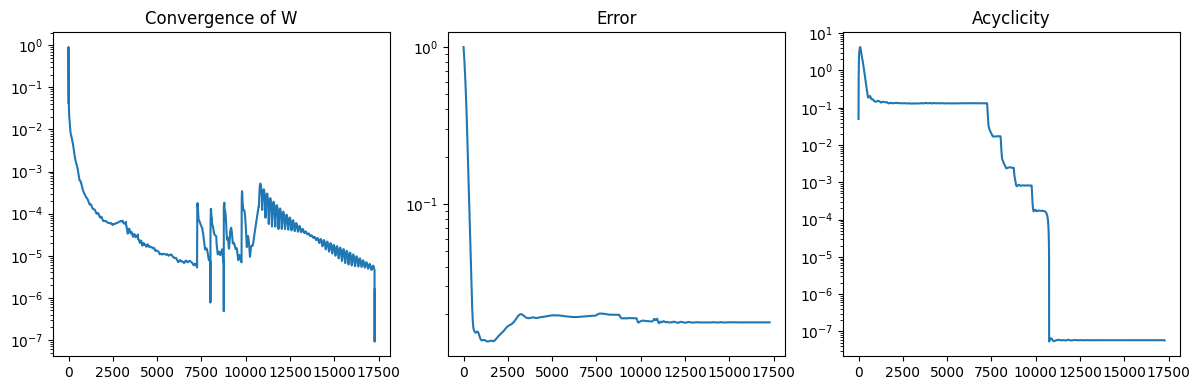

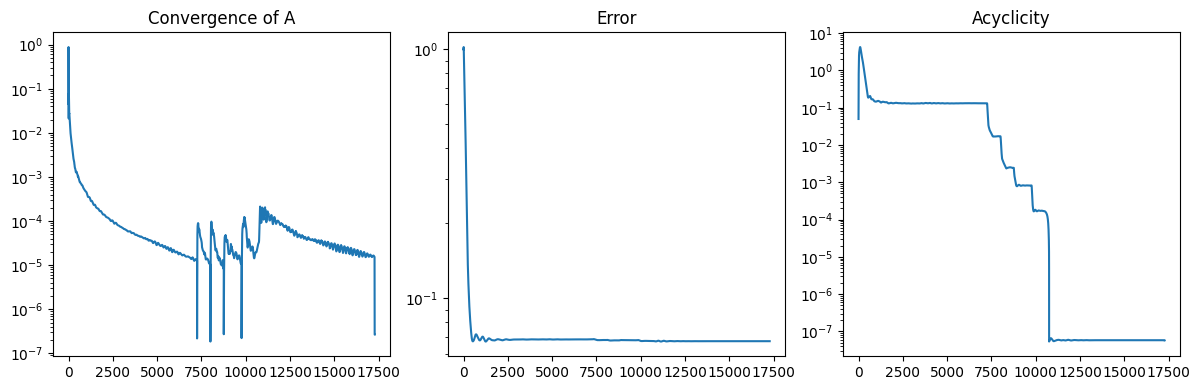

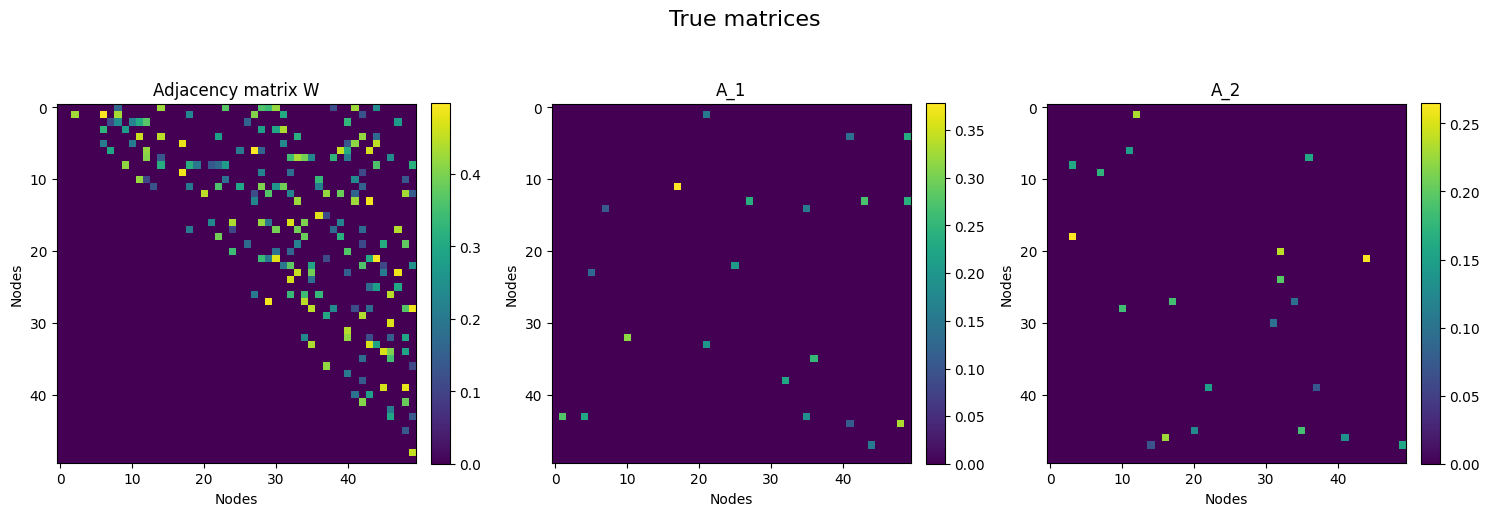

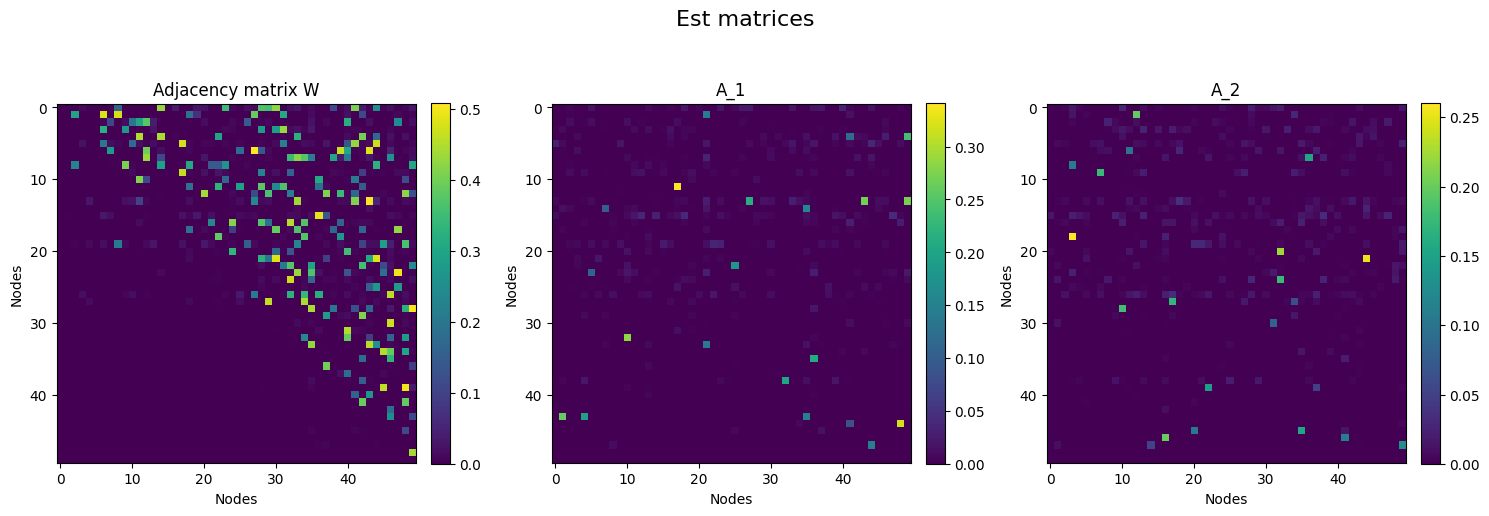

In [9]:
lamb_W = get_lamb_value(N, T, .01)
lamb_A = get_lamb_value(N*n_lags, T, .05)
fit_args = {'stepsize': 3e-4, 'alpha_0': 1, 'rho_0': .05, 's': 1, 'lamb_W': lamb_W, 'lamb_A': lamb_A,
            'iters_in': 10000, 'iters_out': 20, 'tol': 1e-5, 'beta': 5, 'verb': True}

print('lamb_W:', lamb_W, ', lamb_A:', lamb_A)

t_i = time.time()
model = Nonneg_dyn_dag_learning(acyclicity='logdet', primal_opt='fista', restart=False)
W_est, A_est = model.fit(X, Y, **fit_args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .1
plot_convergence(W_true, model.seq_W, model.diff_W, model.acyclicity, matrix='W')
plot_convergence(A_true, model.seq_A, model.diff_A, model.acyclicity, matrix='A')

plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)

### Using APGD - restart

lamb_W: 0.00027971496225365374 , lamb_A: 0.0015174271293851467
Convergence achieved at iter 7251
- 1/20. Diff W: 0.000005 | Diff A: 0.000013 | Acycl: 0.131115 |Rho: 0.250 - Alpha: 1.007 - Step: 0.0003
Convergence achieved at iter 1
- 2/20. Diff W: 0.000008 | Diff A: 0.000000 | Acycl: 0.130976 |Rho: 1.250 - Alpha: 1.039 - Step: 0.0003
Convergence achieved at iter 751
- 3/20. Diff W: 0.000007 | Diff A: 0.000010 | Acycl: 0.017208 |Rho: 1.250 - Alpha: 1.061 - Step: 0.0003
Convergence achieved at iter 1
- 4/20. Diff W: 0.000001 | Diff A: 0.000000 | Acycl: 0.017206 |Rho: 6.250 - Alpha: 1.082 - Step: 0.0003
Convergence achieved at iter 1
- 5/20. Diff W: 0.000005 | Diff A: 0.000000 | Acycl: 0.017195 |Rho: 31.250 - Alpha: 1.190 - Step: 0.0003
Convergence achieved at iter 751
- 6/20. Diff W: 0.000006 | Diff A: 0.000011 | Acycl: 0.002443 |Rho: 31.250 - Alpha: 1.266 - Step: 0.0003
Convergence achieved at iter 1
- 7/20. Diff W: 0.000000 | Diff A: 0.000000 | Acycl: 0.002443 |Rho: 156.250 - Alpha: 1.

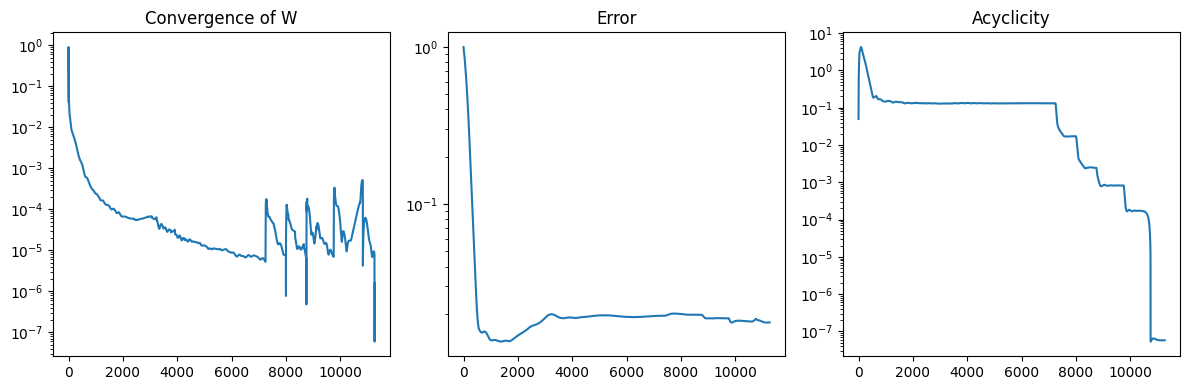

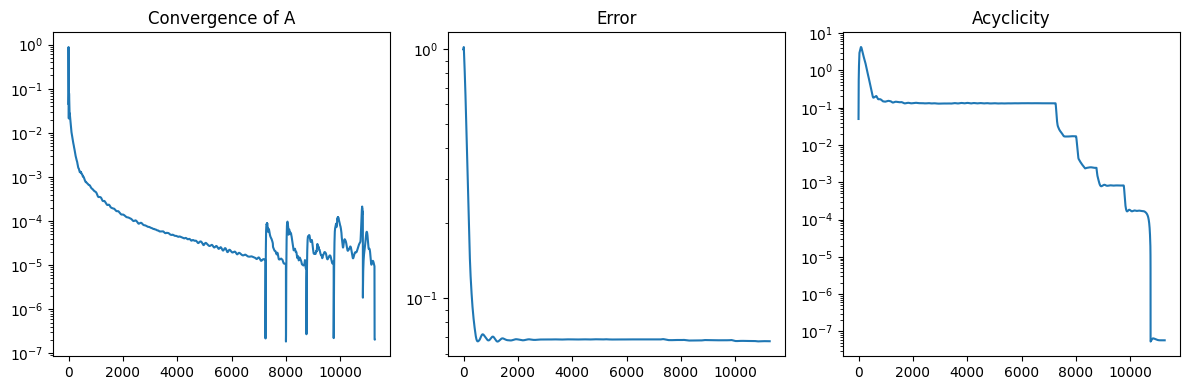

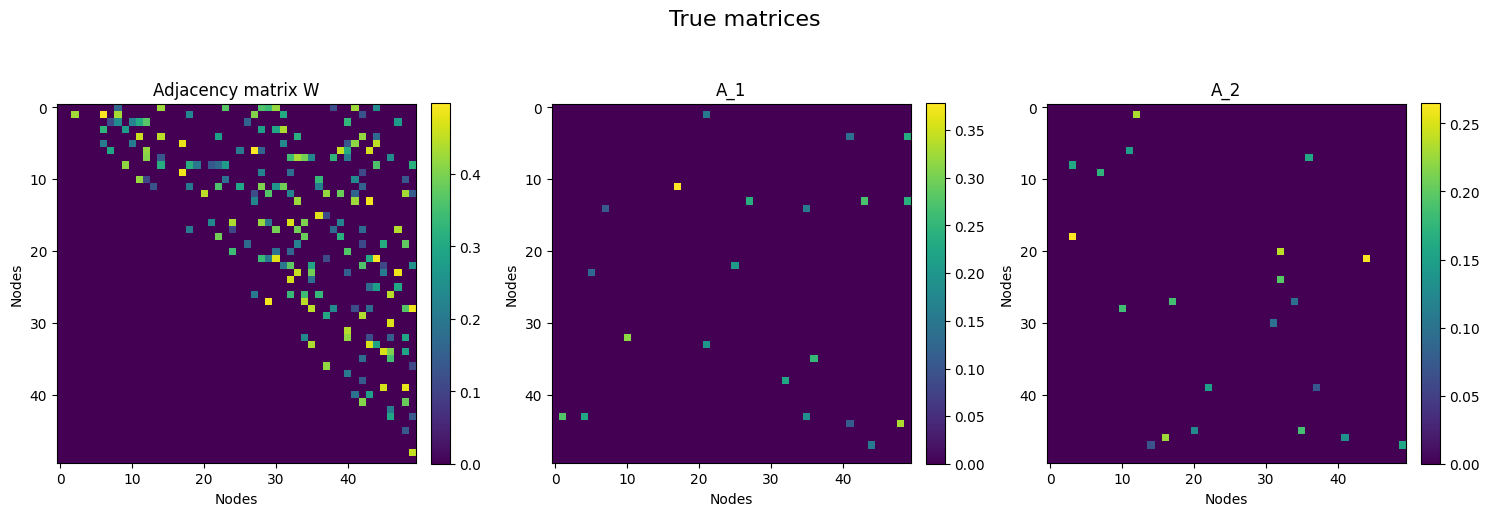

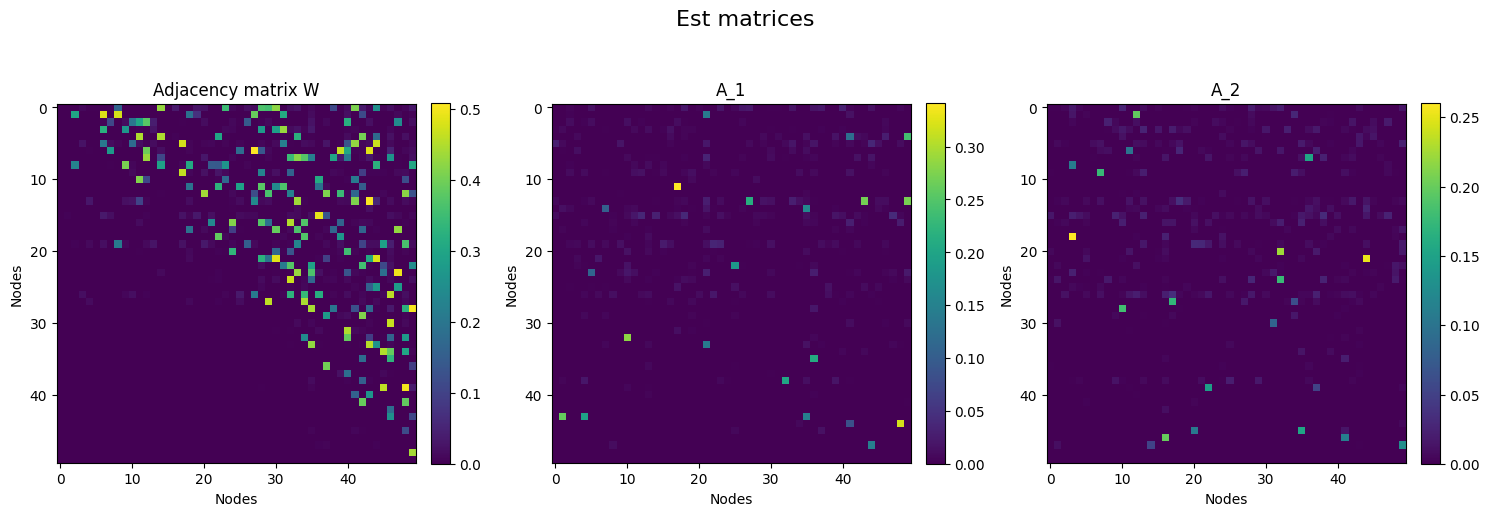

In [10]:
lamb_W = get_lamb_value(N, T, .01)
lamb_A = get_lamb_value(N*n_lags, T, .05)
fit_args = {'stepsize': 3e-4, 'alpha_0': 1, 'rho_0': .05, 's': 1, 'lamb_W': lamb_W, 'lamb_A': lamb_A,
            'iters_in': 10000, 'iters_out': 20, 'tol': 1e-5, 'beta': 5, 'verb': True}

print('lamb_W:', lamb_W, ', lamb_A:', lamb_A)

t_i = time.time()
model = Nonneg_dyn_dag_learning(acyclicity='logdet', primal_opt='fista', restart=True)
W_est, A_est = model.fit(X, Y, **fit_args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .1
plot_convergence(W_true, model.seq_W, model.diff_W, model.acyclicity, matrix='W')
plot_convergence(A_true, model.seq_A, model.diff_A, model.acyclicity, matrix='A')

plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)

### Using SCA

lamb_W: 0.0 , lamb_A: 0.0
- 1/10. Diff W: 0.000041 | Diff A: 0.000008 | Acycl: 8.872802 |Rho: 0.100 - Alpha: 0.544 - Step: 0.0001
- 2/10. Diff W: 0.000019 | Diff A: 0.000004 | Acycl: 2.288680 |Rho: 0.200 - Alpha: 0.773 - Step: 0.0001
- 3/10. Diff W: 0.000009 | Diff A: 0.000002 | Acycl: 0.591928 |Rho: 0.400 - Alpha: 0.891 - Step: 0.0001
- 4/10. Diff W: 0.000004 | Diff A: 0.000001 | Acycl: 0.150709 |Rho: 0.800 - Alpha: 0.951 - Step: 0.0001
- 5/10. Diff W: 0.000002 | Diff A: 0.000001 | Acycl: 0.057895 |Rho: 1.600 - Alpha: 0.997 - Step: 0.0001
- 6/10. Diff W: 0.000002 | Diff A: 0.000000 | Acycl: 0.028079 |Rho: 3.200 - Alpha: 1.042 - Step: 0.0001
- 7/10. Diff W: 0.000002 | Diff A: 0.000000 | Acycl: 0.014368 |Rho: 6.400 - Alpha: 1.088 - Step: 0.0001
- 8/10. Diff W: 0.000002 | Diff A: 0.000000 | Acycl: 0.004444 |Rho: 12.800 - Alpha: 1.117 - Step: 0.0001
- 9/10. Diff W: 0.000001 | Diff A: 0.000000 | Acycl: 0.000447 |Rho: 12.800 - Alpha: 1.123 - Step: 0.0001
- 10/10. Diff W: 0.000002 | Diff A: 

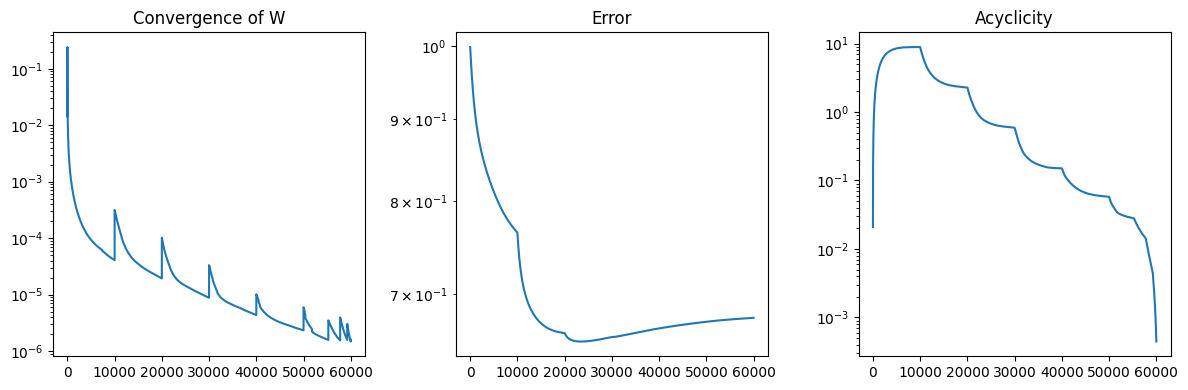

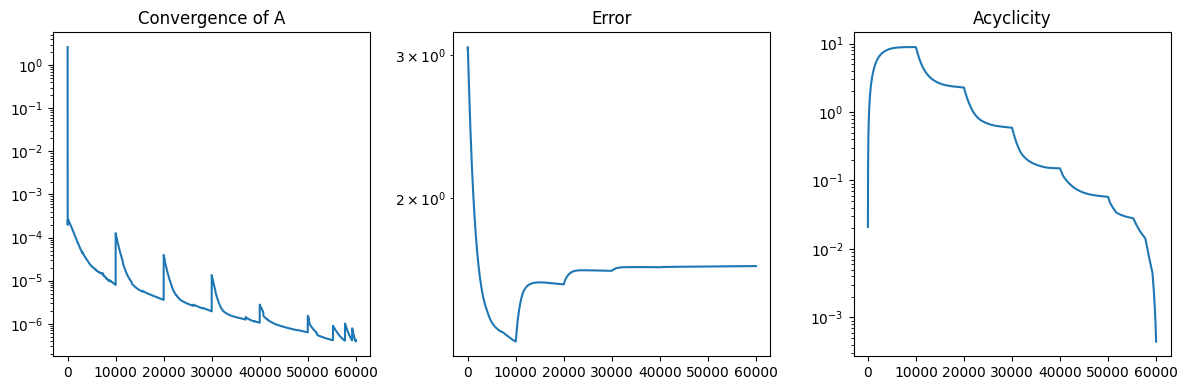

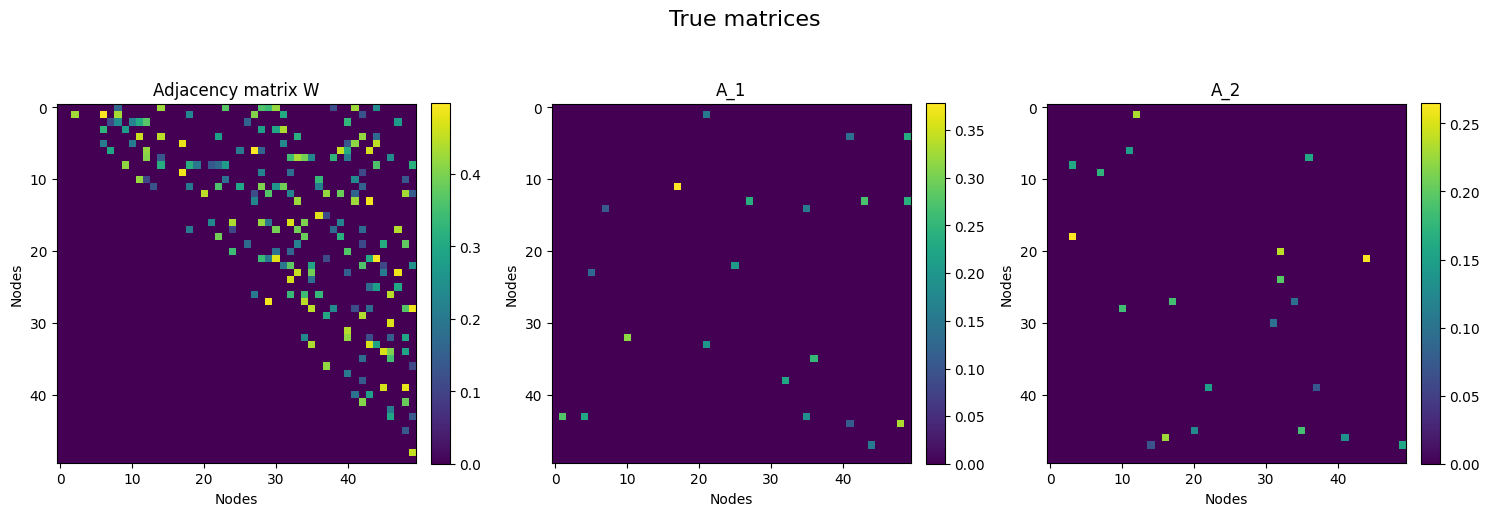

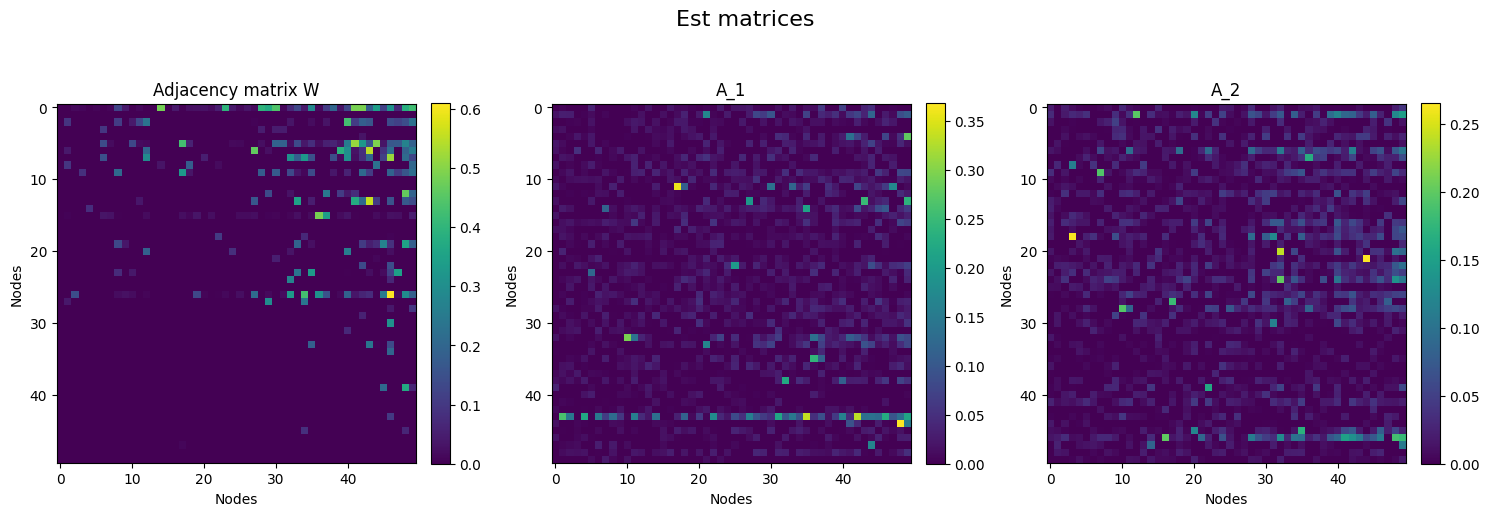

In [11]:
lamb_W = get_lamb_value(N, T, .0)
lamb_A = get_lamb_value(N*n_lags, T, .0)
fit_args = {'stepsize': 1e-4, 'alpha_0': .1, 'rho_0': .05, 's': 1, 'lamb_W': lamb_W, 'lamb_A': lamb_A,
            'iters_in': 10000, 'iters_out': 10, 'beta': 2, 'verb': True}

print('lamb_W:', lamb_W, ', lamb_A:', lamb_A)

t_i = time.time()
model = Nonneg_dyn_dag_learning(acyclicity='logdet', primal_opt='sca')
W_est, A_est = model.fit(X, Y, **fit_args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .1
plot_convergence(W_true, model.seq_W, model.diff_W, model.acyclicity, matrix='W')
plot_convergence(A_true, model.seq_A, model.diff_A, model.acyclicity, matrix='A')

plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)

### Using SCA + ADAM

lamb_W: 0.002797149622536537 , lamb_A: 0.0030348542587702934
- 1/100. Diff W: 0.010232 | Diff A: 0.004252 | Acycl: 6.918878 |Rho: 0.055 - Alpha: 0.446 - Step: 0.0003
- 2/100. Diff W: 0.004211 | Diff A: 0.002001 | Acycl: 7.315858 |Rho: 0.061 - Alpha: 0.848 - Step: 0.0003
- 3/100. Diff W: 0.003160 | Diff A: 0.001043 | Acycl: 2.325019 |Rho: 0.067 - Alpha: 0.989 - Step: 0.0003
- 4/100. Diff W: 0.001460 | Diff A: 0.000510 | Acycl: 0.274382 |Rho: 0.067 - Alpha: 1.007 - Step: 0.0003
- 5/100. Diff W: 0.000804 | Diff A: 0.000270 | Acycl: 0.092336 |Rho: 0.073 - Alpha: 1.013 - Step: 0.0003
- 6/100. Diff W: 0.000510 | Diff A: 0.000167 | Acycl: 0.048902 |Rho: 0.081 - Alpha: 1.017 - Step: 0.0003
- 7/100. Diff W: 0.000344 | Diff A: 0.000096 | Acycl: 0.035392 |Rho: 0.089 - Alpha: 1.020 - Step: 0.0003
- 8/100. Diff W: 0.000219 | Diff A: 0.000067 | Acycl: 0.032811 |Rho: 0.097 - Alpha: 1.023 - Step: 0.0003
- 9/100. Diff W: 0.000144 | Diff A: 0.000058 | Acycl: 0.038006 |Rho: 0.107 - Alpha: 1.026 - Step: 0

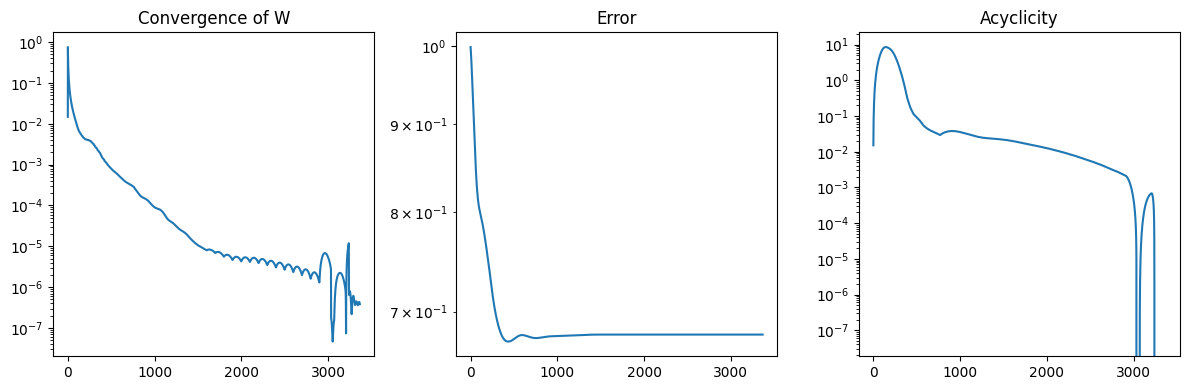

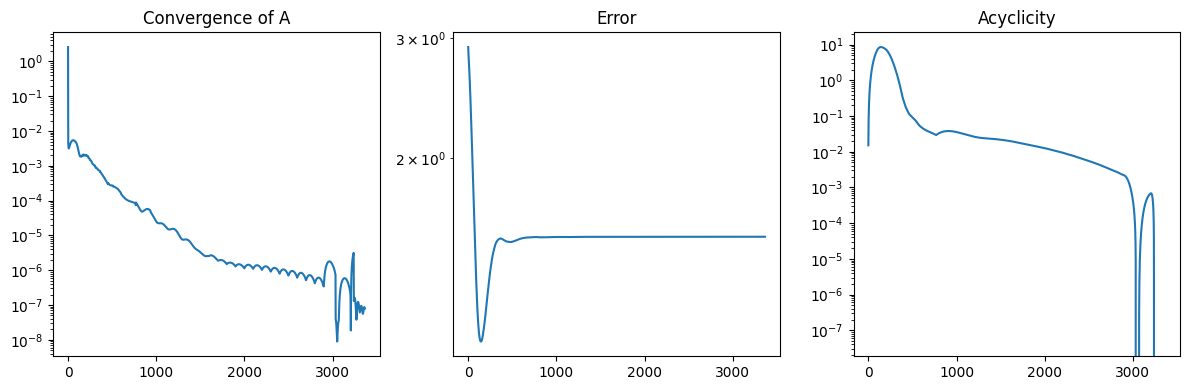

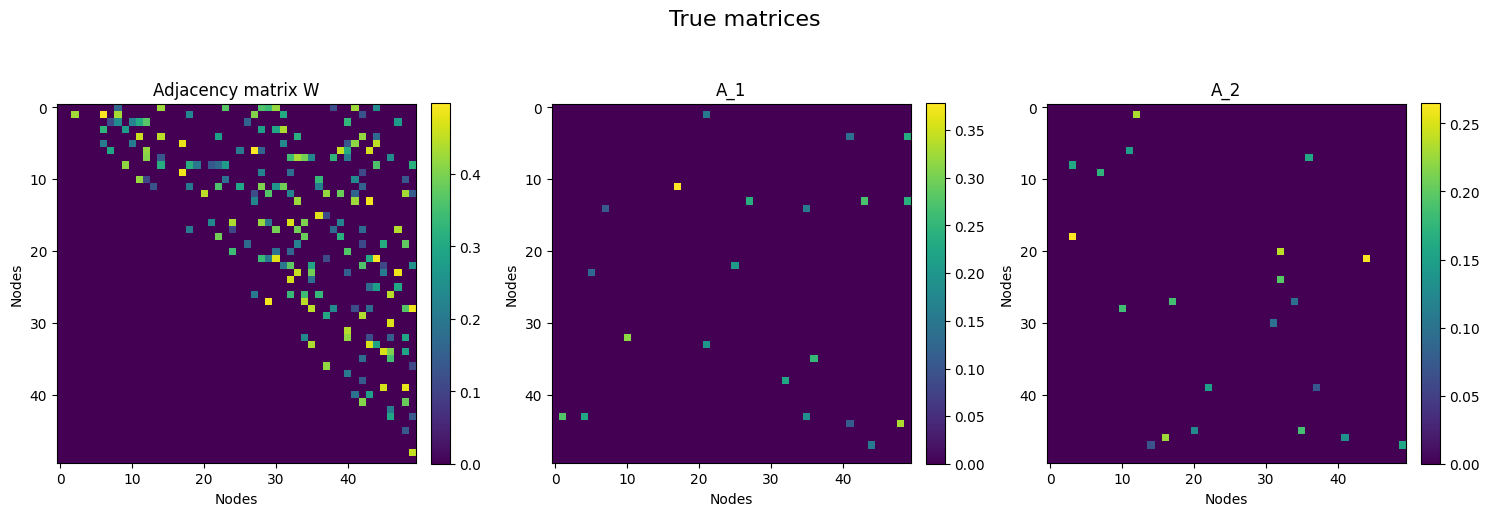

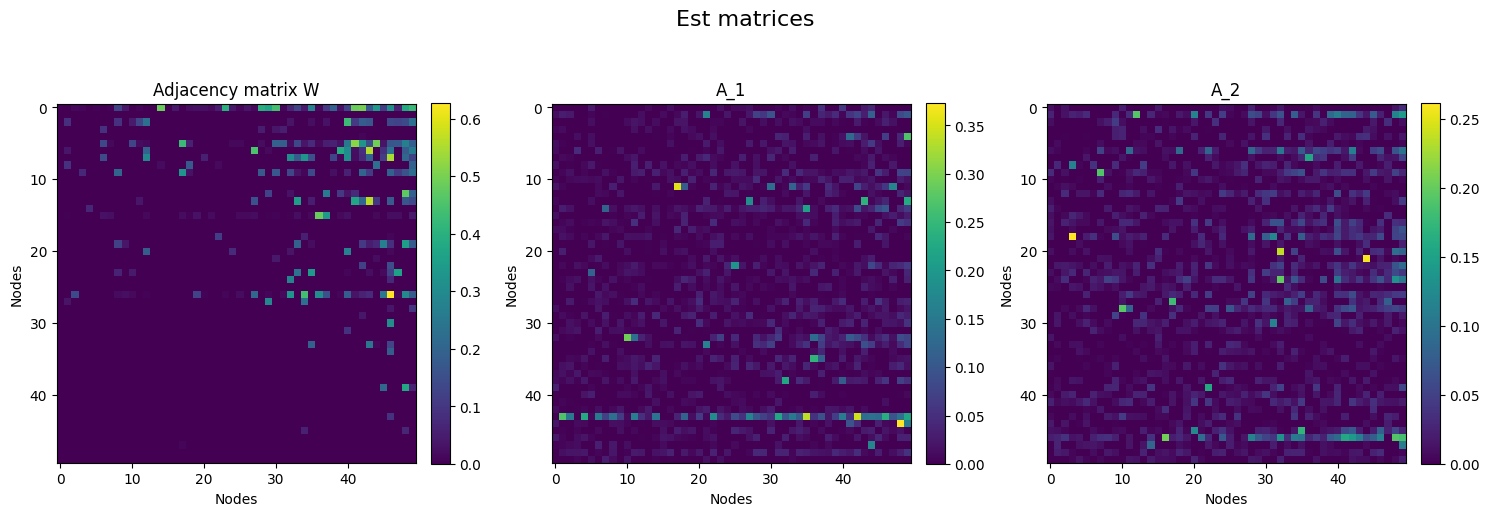

In [12]:
lamb_W = get_lamb_value(N, T, .1)
lamb_A = get_lamb_value(N*n_lags, T, .1)
fit_args = {'stepsize': 3e-4, 'alpha_0': .1, 'rho_0': .05, 's': 1, 'lamb_W': lamb_W, 'lamb_A': lamb_A,
            'iters_in': 100, 'iters_out': 100, 'beta': 1.1, 'verb': True}

print('lamb_W:', lamb_W, ', lamb_A:', lamb_A)

t_i = time.time()
model = Nonneg_dyn_dag_learning(acyclicity='logdet', primal_opt='sca-adam')
W_est, A_est = model.fit(X, Y, **fit_args, track_seq=True)
t_solved = time.time() - t_i
print(f'Solved in {t_solved:3f} seconds')

# Plot description
thr = .1
plot_convergence(W_true, model.seq_W, model.diff_W, model.acyclicity, matrix='W')
plot_convergence(A_true, model.seq_A, model.diff_A, model.acyclicity, matrix='A')

plot_result(W_true, W_est, A_true, A_est, n_lags, thr, plot_matrices=True)


## Data as in DYNOTEARS

In [13]:
# # Create the DAG and its adjacency matrix with the given utility
# N =5
# n_samples = 20
# g_type='er'
# dag_w_range = (.5, 2)
# edges = 4*N
# n_lags = 3
# edges_inter = N
# exp_decay = 1.5
# lag_w_range = (.3, .5)

# W, dag, A, lag_graphs, X, Y = utils.simulate_svar(N, n_samples, g_type, edges,dag_permute=False, dag_w_range=dag_w_range,
#                                                   n_lags=n_lags, er_edges=edges_inter, lag_w_range=lag_w_range,
#                                                   exp_decay=exp_decay)
# W_bin = (W != 0).astype(int)
# A_bin = (A != 0).astype(int)
# avg_W_deg = W_bin.sum(axis=0).mean()
# avg_A_deg = A_bin.sum(axis=0).mean()
# print(f"Average out-degree W: {avg_W_deg:.3f}")
# print(f"Average out-degree A: {avg_A_deg:.3f}")

# print(A[N:,:].max())

# WA = np.vstack([W, A])   # shape: ((n_lags+1)*N, N)
# print("||[W;A]||_∞ =", np.linalg.norm(WA, ord=np.inf))
# print("||[W]||_∞   =", np.linalg.norm(W,  ord=np.inf))
# print("||[A]||_∞   =", np.linalg.norm(A,  ord=np.inf))


# # --- Figure 1: Adjacency matrix ---
# plt.figure(figsize=(6, 5))
# # Display the matrix as a colored image
# plt.imshow(W, cmap="viridis", interpolation="nearest")
# plt.colorbar()  # color bar for the scale
# plt.title("Adjacency matrix W")
# plt.xlabel("Nodes (columns)")
# plt.ylabel("Nodes (rows)")
# plt.show()

# # --- Figure 2: Interslice adjacency matrices ---
# n_lags = len(lag_graphs)

# fig, axes = plt.subplots(1, n_lags, figsize=(6*n_lags, 5), squeeze=False)

# for k, Gk in enumerate(lag_graphs, start=1):
#     Ak = nx.to_numpy_array(Gk)   # adjacency matrix for lag k
#     ax = axes[0, k-1]
#     im = ax.imshow(Ak, cmap="viridis", interpolation="nearest")
#     ax.set_title(f"A_{k}")
#     ax.set_xlabel("Nodes (columns)")
#     ax.set_ylabel("Nodes (rows)")
#     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# plt.tight_layout()
# plt.show()

In [14]:
# plt.figure(figsize=(6, 5))
# # Display the matrix as a colored image
# plt.imshow(X, cmap="viridis", interpolation="nearest")
# plt.colorbar()  # color bar for the scale
# plt.title("X")
# plt.xlabel("Nodes (columns)")
# plt.ylabel("Nodes (rows)")
# plt.show()

# plt.figure(figsize=(6, 5))
# # Display the matrix as a colored image
# plt.imshow(Y, cmap="viridis", interpolation="nearest")
# plt.colorbar()  # color bar for the scale
# plt.title("Y")
# plt.xlabel("Nodes (columns)")
# plt.ylabel("Nodes (rows)")
# plt.show()
